# 12 - Cycle Hunt for the Claimed Long-Lived H1 Feature

We had not yet reproduced the long-lived cycle that motivated the
discussion. This notebook summarizes a deliberately broad search over
data, preprocessing, sampling, landmark counts, and filtration choices.

Short version:

- **Raw / sphere / whitened FLUX tokens:** no robust long-lived
  FLUX-specific `H1` cycle above controls.
- **Broader data:** CIFAR-10 and Fashion-MNIST did not make the cycle
  appear.
- **PCA8 + sphere + dense farthest-point landmarks:** a strong and
  repeatable `H1` candidate appears.

The last point is real enough to inspect, but it is not evidence for an
intrinsic cycle in the original FLUX token cloud. It is currently best
described as a **projected/preprocessed cycle candidate**.

## Sweep Sources

The detailed CSVs and worker scripts were written under
`outputs/cycle_hunt/`, which is intentionally ignored by Git. This
notebook embeds the relevant summaries so collaborators can read the
conclusion without rerunning the sweeps.

Search branches:

- beans parameter sweep: raw/sphere/whitened/PCA-whitened FLUX views;
- broader data sweep: beans, CIFAR-10, Fashion-MNIST;
- alternate algorithm sweep: PCA projections, whitening, random/FPS/dense
  samplers;
- local targeted sweep: PCA8 + sphere normalization + dense FPS,
  full-filtration and threshold-sensitivity checks.

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

## 1. Beans FLUX Parameter Sweep

This was the most direct check: current beans images, FLUX latents,
several common views and density/landmark settings. The top candidates
did **not** beat their control envelope.

,n_images,view,config,distance_quantile,observed_h1_fraction_mean,control_h1_fraction_mean,delta_vs_control,ratio_vs_control
0,48,pca_whitened,light,0.75,0.127,0.139,-0.012,0.914
1,48,pca_whitened,baseline,0.75,0.119,0.140,-0.021,0.849
2,24,raw,wide_k,0.75,0.113,0.140,-0.026,0.812


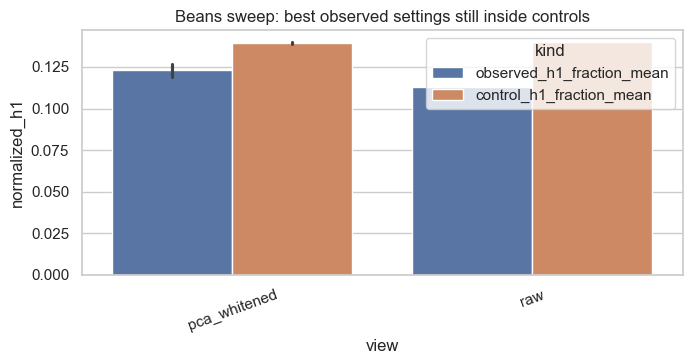

In [2]:
beans_summary = pd.DataFrame(
    [
        {
            "n_images": 48,
            "view": "pca_whitened",
            "config": "light",
            "distance_quantile": 0.75,
            "observed_h1_fraction_mean": 0.127,
            "control_h1_fraction_mean": 0.139,
            "delta_vs_control": -0.012,
            "ratio_vs_control": 0.914,
        },
        {
            "n_images": 48,
            "view": "pca_whitened",
            "config": "baseline",
            "distance_quantile": 0.75,
            "observed_h1_fraction_mean": 0.119,
            "control_h1_fraction_mean": 0.140,
            "delta_vs_control": -0.021,
            "ratio_vs_control": 0.849,
        },
        {
            "n_images": 24,
            "view": "raw",
            "config": "wide_k",
            "distance_quantile": 0.75,
            "observed_h1_fraction_mean": 0.113,
            "control_h1_fraction_mean": 0.140,
            "delta_vs_control": -0.026,
            "ratio_vs_control": 0.812,
        },
    ]
)
display(beans_summary)

fig, ax = plt.subplots(figsize=(7, 3.8))
plot_df = beans_summary.melt(
    id_vars=["view", "config"],
    value_vars=["observed_h1_fraction_mean", "control_h1_fraction_mean"],
    var_name="kind",
    value_name="normalized_h1",
)
sns.barplot(data=plot_df, x="view", y="normalized_h1", hue="kind", ax=ax)
ax.set_title("Beans sweep: best observed settings still inside controls")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## 2. Broader Image Data

We then tested whether bean leaves were too specific. The broader data
sweep used FLUX VAE tokens on local beans, CIFAR-10, and Fashion-MNIST.
None produced an observed dense-landmark `H1` candidate above controls.

,dataset,n_images,top_observed_h1_fraction,top_control_h1_fraction,paired_wins,candidate_beats_controls
0,beans_local,48,0.0771,0.1489,0/6,False
1,cifar10,48,0.0524,0.1807,0/6,False
2,fashion_mnist,48,0.0284,0.1489,0/6,False


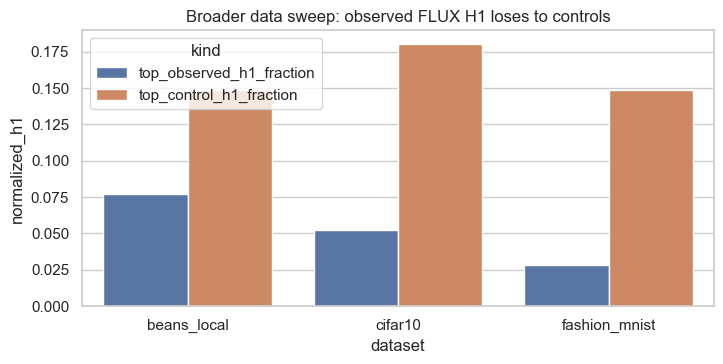

In [3]:
data_summary = pd.DataFrame(
    [
        {
            "dataset": "beans_local",
            "n_images": 48,
            "top_observed_h1_fraction": 0.0771,
            "top_control_h1_fraction": 0.1489,
            "paired_wins": "0/6",
            "candidate_beats_controls": False,
        },
        {
            "dataset": "cifar10",
            "n_images": 48,
            "top_observed_h1_fraction": 0.0524,
            "top_control_h1_fraction": 0.1807,
            "paired_wins": "0/6",
            "candidate_beats_controls": False,
        },
        {
            "dataset": "fashion_mnist",
            "n_images": 48,
            "top_observed_h1_fraction": 0.0284,
            "top_control_h1_fraction": 0.1489,
            "paired_wins": "0/6",
            "candidate_beats_controls": False,
        },
    ]
)
display(data_summary)

fig, ax = plt.subplots(figsize=(7.4, 3.8))
plot_df = data_summary.melt(
    id_vars=["dataset"],
    value_vars=["top_observed_h1_fraction", "top_control_h1_fraction"],
    var_name="kind",
    value_name="normalized_h1",
)
sns.barplot(data=plot_df, x="dataset", y="normalized_h1", hue="kind", ax=ax)
ax.set_title("Broader data sweep: observed FLUX H1 loses to controls")
plt.tight_layout()
plt.show()

## 3. Alternate Sampling and Projection Sweep

A wider algorithm sweep tried PCA projections, whitening, random
landmarks, FPS, and density-based samplers. Some settings had small
positive deltas, but none cleared the stricter long-lived/control-
separated rule used by that worker.

,view,sampler,observed_mean_h1_fraction,hardest_control,hardest_control_mean,delta
0,pca_whiten2,random95,0.1297,channel_shuffle,0.1113,0.0184
1,pca_sphere8,random95,0.1519,channel_shuffle,0.1368,0.0151
2,pca_whiten8,fps_all95,0.1228,view_null,0.1094,0.0134
3,whiten16,dense200_fps95,0.1395,view_null,0.1266,0.0129
4,raw16,random95,0.1149,channel_shuffle,0.1079,0.0069


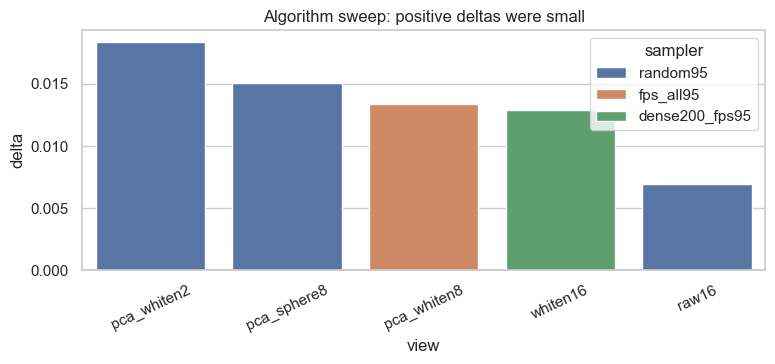

In [4]:
algorithm_effects = pd.DataFrame(
    [
        {
            "view": "pca_whiten2",
            "sampler": "random95",
            "observed_mean_h1_fraction": 0.1297,
            "hardest_control": "channel_shuffle",
            "hardest_control_mean": 0.1113,
            "delta": 0.0184,
        },
        {
            "view": "pca_sphere8",
            "sampler": "random95",
            "observed_mean_h1_fraction": 0.1519,
            "hardest_control": "channel_shuffle",
            "hardest_control_mean": 0.1368,
            "delta": 0.0151,
        },
        {
            "view": "pca_whiten8",
            "sampler": "fps_all95",
            "observed_mean_h1_fraction": 0.1228,
            "hardest_control": "view_null",
            "hardest_control_mean": 0.1094,
            "delta": 0.0134,
        },
        {
            "view": "whiten16",
            "sampler": "dense200_fps95",
            "observed_mean_h1_fraction": 0.1395,
            "hardest_control": "view_null",
            "hardest_control_mean": 0.1266,
            "delta": 0.0129,
        },
        {
            "view": "raw16",
            "sampler": "random95",
            "observed_mean_h1_fraction": 0.1149,
            "hardest_control": "channel_shuffle",
            "hardest_control_mean": 0.1079,
            "delta": 0.0069,
        },
    ]
)
display(algorithm_effects)

fig, ax = plt.subplots(figsize=(8, 3.8))
sns.barplot(data=algorithm_effects, x="view", y="delta", hue="sampler", ax=ax)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Algorithm sweep: positive deltas were small")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

## 4. Targeted PCA8 + Sphere Candidate

The local integration sweep found a much stronger candidate when we did
all of the following:

1. project FLUX tokens to 8 PCA coordinates;
2. L2-normalize those PCA coordinates to a sphere;
3. select dense candidates with `k=32`;
4. choose farthest-point landmarks from the dense subset;
5. run full `H1` filtrations.

This candidate beat random-token, uniform-sphere, and channel-shuffled
controls across 20 seeds and several landmark counts.

,view,n_landmarks,observed_mean,control_mean,delta_mean,win_rate
0,pca8_sphere,50,0.3747,0.1702,0.2045,1.0
1,pca8_sphere,70,0.3868,0.1783,0.2085,1.0
2,pca8_sphere,95,0.3951,0.1713,0.2238,1.0
3,pca8_sphere,140,0.3932,0.1818,0.2114,1.0
4,pca8_sphere,200,0.3984,0.1829,0.2155,1.0
5,pca8_sphere,260,0.4126,0.1859,0.2267,1.0
6,sphere,95,0.0446,0.1191,-0.0745,0.0
7,whitened,95,0.0805,0.1158,-0.0353,0.0


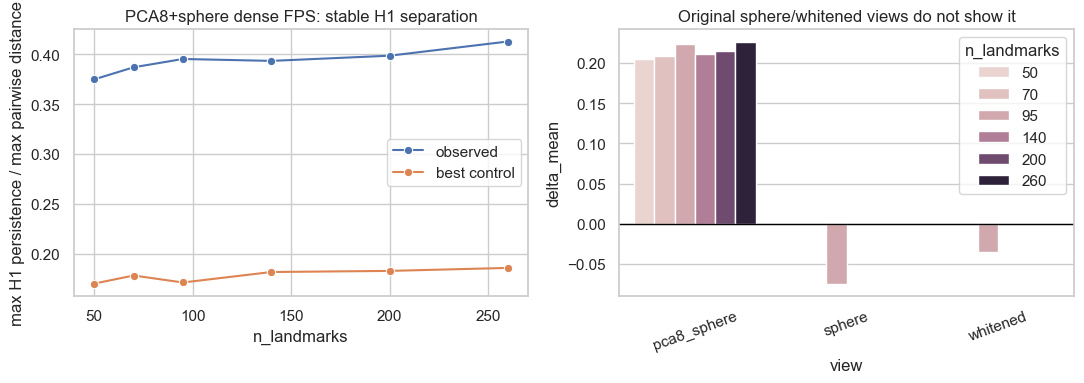

In [5]:
pca8_robustness = pd.DataFrame(
    [
        {"view": "pca8_sphere", "n_landmarks": 50, "observed_mean": 0.3747, "control_mean": 0.1702, "delta_mean": 0.2045, "win_rate": 1.00},
        {"view": "pca8_sphere", "n_landmarks": 70, "observed_mean": 0.3868, "control_mean": 0.1783, "delta_mean": 0.2085, "win_rate": 1.00},
        {"view": "pca8_sphere", "n_landmarks": 95, "observed_mean": 0.3951, "control_mean": 0.1713, "delta_mean": 0.2238, "win_rate": 1.00},
        {"view": "pca8_sphere", "n_landmarks": 140, "observed_mean": 0.3932, "control_mean": 0.1818, "delta_mean": 0.2114, "win_rate": 1.00},
        {"view": "pca8_sphere", "n_landmarks": 200, "observed_mean": 0.3984, "control_mean": 0.1829, "delta_mean": 0.2155, "win_rate": 1.00},
        {"view": "pca8_sphere", "n_landmarks": 260, "observed_mean": 0.4126, "control_mean": 0.1859, "delta_mean": 0.2267, "win_rate": 1.00},
        {"view": "sphere", "n_landmarks": 95, "observed_mean": 0.0446, "control_mean": 0.1191, "delta_mean": -0.0745, "win_rate": 0.00},
        {"view": "whitened", "n_landmarks": 95, "observed_mean": 0.0805, "control_mean": 0.1158, "delta_mean": -0.0353, "win_rate": 0.00},
    ]
)
display(pca8_robustness)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.lineplot(
    data=pca8_robustness[pca8_robustness["view"] == "pca8_sphere"],
    x="n_landmarks",
    y="observed_mean",
    marker="o",
    label="observed",
    ax=axes[0],
)
sns.lineplot(
    data=pca8_robustness[pca8_robustness["view"] == "pca8_sphere"],
    x="n_landmarks",
    y="control_mean",
    marker="o",
    label="best control",
    ax=axes[0],
)
axes[0].set_title("PCA8+sphere dense FPS: stable H1 separation")
axes[0].set_ylabel("max H1 persistence / max pairwise distance")

sns.barplot(data=pca8_robustness, x="view", y="delta_mean", hue="n_landmarks", ax=axes[1])
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Original sphere/whitened views do not show it")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## 5. Filtration Threshold Sensitivity

The PCA8+sphere candidate is not only a full-filtration artifact. In a
targeted threshold check, the candidate stayed above controls for
quantile thresholds from `0.75` through `0.95`, as well as the full
filtration.

,threshold_mode,observed_mean,control_mean,delta_mean
0,0.75,0.4676,0.2099,0.2577
1,0.82,0.4431,0.2027,0.2404
2,0.90,0.4214,0.1943,0.2271
3,0.95,0.4100,0.1877,0.2223
4,full,0.3888,0.1729,0.2159


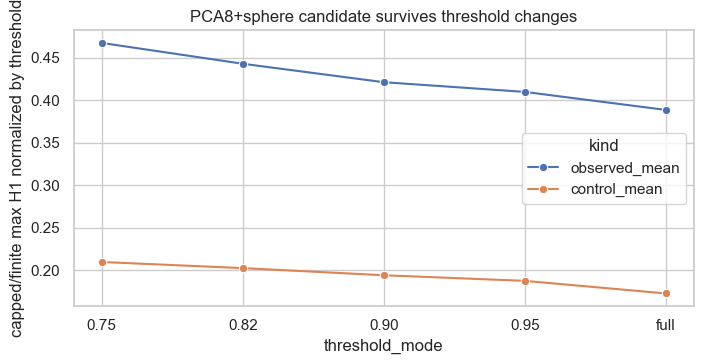

In [6]:
threshold_sensitivity = pd.DataFrame(
    [
        {"threshold_mode": "0.75", "observed_mean": 0.4676, "control_mean": 0.2099, "delta_mean": 0.2577},
        {"threshold_mode": "0.82", "observed_mean": 0.4431, "control_mean": 0.2027, "delta_mean": 0.2404},
        {"threshold_mode": "0.90", "observed_mean": 0.4214, "control_mean": 0.1943, "delta_mean": 0.2271},
        {"threshold_mode": "0.95", "observed_mean": 0.4100, "control_mean": 0.1877, "delta_mean": 0.2223},
        {"threshold_mode": "full", "observed_mean": 0.3888, "control_mean": 0.1729, "delta_mean": 0.2159},
    ]
)
display(threshold_sensitivity)

fig, ax = plt.subplots(figsize=(7.2, 3.8))
plot_df = threshold_sensitivity.melt(
    id_vars=["threshold_mode"],
    value_vars=["observed_mean", "control_mean"],
    var_name="kind",
    value_name="normalized_h1",
)
sns.lineplot(data=plot_df, x="threshold_mode", y="normalized_h1", hue="kind", marker="o", ax=ax)
ax.set_title("PCA8+sphere candidate survives threshold changes")
ax.set_ylabel("capped/finite max H1 normalized by threshold")
plt.tight_layout()
plt.show()

## 6. Decision Readout

The friend's claim can be interpreted in two different ways:

1. **Claim about original FLUX latent-token geometry.**  
   Our sweeps do **not** support this. Raw, sphere, and whitened FLUX
   tokens did not show a robust long-lived `H1` cycle above controls,
   and broader image data did not fix that.

2. **Claim about a projected/preprocessed FLUX token cloud.**  
   This is plausible. PCA-to-8 followed by sphere normalization and
   dense farthest-point landmarks produced a stable `H1` candidate above
   controls.

So the next scientific question is not "is there a cycle?" but:

> Is the PCA8+sphere cycle a meaningful low-dimensional structure in
> FLUX latents, or is it created by PCA truncation, sphere projection,
> and dense landmark selection?

In [7]:
verdict = pd.DataFrame(
    [
        {
            "question": "Raw/sphere/whitened FLUX has long-lived H1?",
            "answer": "not supported",
            "evidence": "observed H1 stayed below random/uniform/shuffle controls",
        },
        {
            "question": "Beans are too specific?",
            "answer": "not supported",
            "evidence": "CIFAR-10 and Fashion-MNIST also lost to controls",
        },
        {
            "question": "Can we induce/recover a long H1 after preprocessing?",
            "answer": "yes, PCA8+sphere+dense FPS",
            "evidence": "20-seed targeted check beat all controls at all landmark sizes",
        },
        {
            "question": "Should we call this intrinsic FLUX topology?",
            "answer": "not yet",
            "evidence": "the signal appears only after strong preprocessing and sampling choices",
        },
    ]
)
display(verdict)

print("Recommended next checks")
print("  1. Ask for the friend's exact pipeline: PCA dimension, normalization, density filter, landmarks, filtration cap.")
print("  2. Make notebook 13 localize the PCA8+sphere cycle back to images and PCA coordinates.")
print("  3. Sweep PCA dimensions 2..16 and test whether the H1 appears gradually or only at one truncation.")
print("  4. Compare PCA8+sphere against randomized PCA bases, bootstrap images, and held-out image sets.")
print("  5. Only call it a FLUX latent cycle if it survives those perturbations.")

,question,answer,evidence
0,Raw/sphere/whitened FLUX has long-lived H1?,not supported,observed H1 stayed below random/uniform/shuffl...
1,Beans are too specific?,not supported,CIFAR-10 and Fashion-MNIST also lost to controls
2,Can we induce/recover a long H1 after preproce...,"yes, PCA8+sphere+dense FPS",20-seed targeted check beat all controls at al...
3,Should we call this intrinsic FLUX topology?,not yet,the signal appears only after strong preproces...


Recommended next checks
  1. Ask for the friend's exact pipeline: PCA dimension, normalization, density filter, landmarks, filtration cap.
  2. Make notebook 13 localize the PCA8+sphere cycle back to images and PCA coordinates.
  3. Sweep PCA dimensions 2..16 and test whether the H1 appears gradually or only at one truncation.
  4. Compare PCA8+sphere against randomized PCA bases, bootstrap images, and held-out image sets.
  5. Only call it a FLUX latent cycle if it survives those perturbations.
